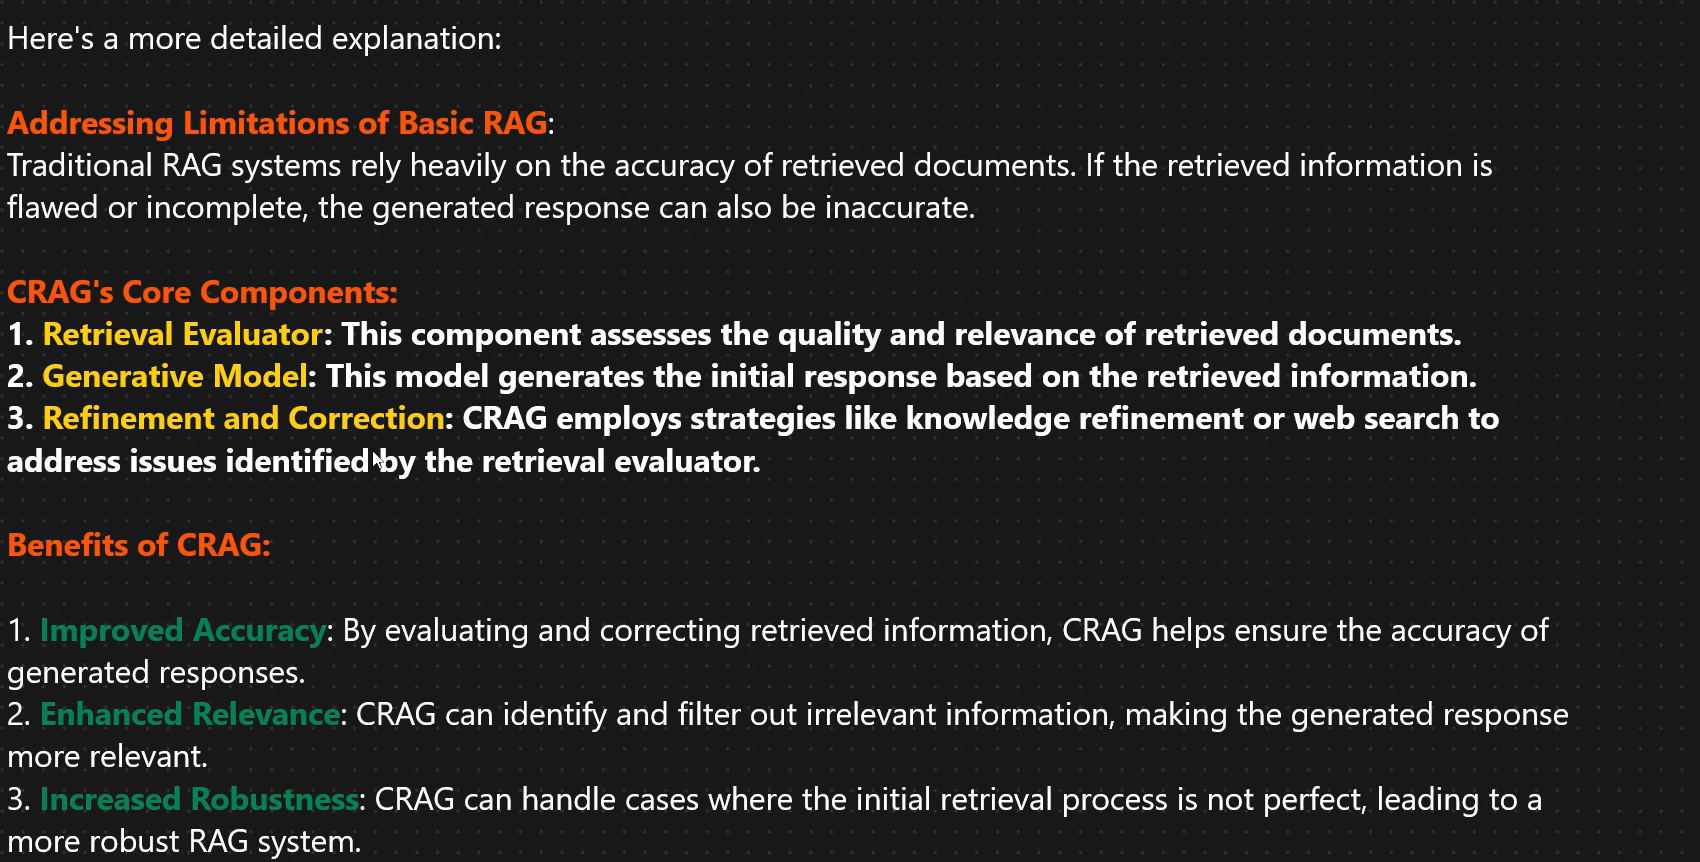

In [1]:
1+1

2

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()  # loading all the environment variables

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings

# Set embeddings
embd = OllamaEmbeddings(model="nomic-embed-text")

# Docs to index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

# Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]
# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500,
    chunk_overlap=0,
)

doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorstore
vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=embd,  # Uses the embeddings object created above
)

retriever = vectorstore.as_retriever()

C:\Users\tejas\AppData\Local\Temp\ipykernel_21920\2059192123.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
### Retrieval Grader
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# LLM with structured output
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

structured_llm_grader = llm.with_structured_output(GradeDocuments)
# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question.
If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant.
Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Retrieved document:\n\n{document}\n\nUser question: {question}",
        ),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

question = "agent memory"
docs = retriever.invoke(question)

doc_txt = docs[1].page_content

print(
    retrieval_grader.invoke(
        {
            "question": question,
            "document": doc_txt,
        }
    )
)



binary_score='yes'


In [6]:
### Generate

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

# Prompt
prompt = ChatPromptTemplate.from_template("""
Use the following context to answer the question.

Context:
{context}

Question:
{question}

Answer:
""")

# LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke(
    {
        "context": format_docs(docs),
        "question": question,
    }
)

print(generation)

The agent's memory can be categorized into several types, similar to human memory. These include:

1. **Sensory Memory**: This is the earliest stage of memory, providing the ability to retain impressions of sensory information after the original stimuli have ended. Sensory memory typically only lasts for up to a few seconds.

2. **Short-Term Memory (STM) or Working Memory**: It stores information that the agent is currently aware of and needed to carry out complex cognitive tasks. Short-term memory is believed to have a limited capacity and lasts for a short period.

3. **Long-Term Memory (LTM)**: Long-term memory can store information for a remarkably long time, with an essentially unlimited storage capacity. There are two subtypes of LTM:
   - **Explicit / Declarative Memory**: This is memory of facts and events, and refers to those memories that can be consciously recalled.
   - **Implicit / Procedural Memory**: This type of memory is unconscious and involves skills and routines tha

In [8]:
### Question Re-writer

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

# Prompt
system = """You are a question re-writer that converts an input question to a better version that is optimized for web search.
Look at the input and try to reason about the underlying semantic intent / meaning."""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question:\n\n{question}\n\nFormulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()

question_rewriter.invoke(
    {
        "question": question
    }
)

'Here\'s a rewritten version of the question:\n\n"What is agent memory in artificial intelligence and how does it work?"\n\nThis revised question provides more context and clarity, making it easier to find relevant and accurate information through a web search. Alternatively, other possible rewritten questions could be:\n\n* "Types of agent memory in multi-agent systems"\n* "Agent memory management in AI programming"\n* "How does agent memory affect decision-making in artificial intelligence?"\n\nThese revised questions help to narrow down the search results and provide more specific information related to the topic of agent memory.'

In [9]:
### Search

from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

C:\Users\tejas\AppData\Local\Temp\ipykernel_21920\730760015.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


In [10]:
from typing import List
from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

In [11]:
from langchain_core.documents import Document

def retrieve(state):
    """
    Retrieve documents
    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents,
                      that contains retrieved documents
    """

    print("---RETRIEVE---")
    question = state["question"]
    # Retrieval
    documents = retriever.invoke(question)

    return {
        "documents": documents,
        "question": question,
    }

def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation,
                      that contains LLM generation
    """

    print("---GENERATE---")

    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke(
        {
            "context": documents,
            "question": question,
        }
    )

    return {
        "documents": documents,
        "question": question,
        "generation": generation,
    }

def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")

    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search = "No"

    for d in documents:
        score = retrieval_grader.invoke(
            {
                "question": question,
                "document": d.page_content,
            }
        )
        grade = score.binary_score

        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)

        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue

    return {
        "documents": filtered_docs,
        "question": question,
        "web_search": web_search,
    }

def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")

    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke(
        {
            "question": question,
        }
    )

    return {
        "documents": documents,
        "question": better_question,
    }

def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")

    question = state["question"]
    documents = state["documents"]

    # Web search
    docs = web_search_tool.invoke(
        {
            "query": question,
        }
    )

    web_results = "\n".join([d["content"] for d in docs])

    web_results = Document(
        page_content=web_results
    )

    documents.append(web_results)

    return {
        "documents": documents,
        "question": question,
    }

def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")

    question = state["question"]
    web_search = state["web_search"]
    documents = state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query

        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )

        return "transform_query"

    else:
        # We have relevant documents, so generate answer

        print(
            "---DECISION: GENERATE---"
        )

        return "generate"

In [13]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)

workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

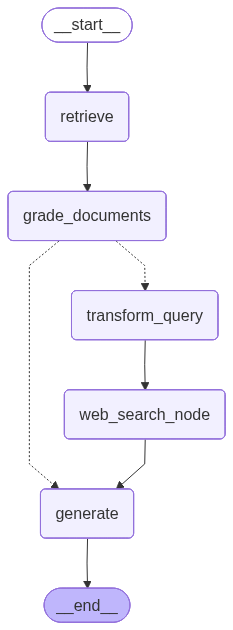

In [14]:
from IPython.display import display,Image

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [15]:
app.invoke({"question":"what are the types of agent memory?"})

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---


{'question': 'Here\'s a rewritten version of the question:\n\n"What are the different types of memory models used in artificial intelligence agents?"\n\nThis revised question is more specific and targeted, which can help yield more accurate and relevant search results. It also adds context by mentioning "artificial intelligence agents", which can help narrow down the search to the intended domain.',
 'generation': 'The different types of memory models used in artificial intelligence agents include:\n\n1. **Short-term memory** (also known as working memory or in-context memory): This type of memory refers to the ability of an AI agent to store and recall information within a short period, typically within a single conversation or interaction.\n2. **Long-term memory**: This type of memory refers to the ability of an AI agent to store and recall information over an extended period, often by leveraging an external vector store and fast retrieval.\n3. **Episodic memory**: This type of memor